# 04 — Bike Sharing Time Series Regression
This notebook develops and evaluates time-series regression models for bike-sharing demand.
The analysis focuses on identifying the main temporal, calendar, weather, and user-behavior factors associated with daily rental demand while accounting for time dependence in the data.

Three response variables are analyzed separately:

- `cnt`: total daily rentals
- `casual`: daily rentals by casual users
- `registered`: daily rentals by registered users

The analysis follows this sequence:

1. Reproduce the OLS baseline estimated in JMP.
2. Diagnose serial correlation in the OLS residuals.
3. Estimate regression models with AR(1) errors.
4. Compare coefficients, uncertainty, model fit, and residual diagnostics.
5. Conduct targeted sensitivity checks.

No observations are deleted or imputed in the main analysis.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels
import statsmodels.api as sm
from patsy import dmatrices
from patsy.contrasts import Sum
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox

In [2]:
print("python version:", sys.version.split()[0])
print("pandas version:", pd.__version__)
print("statsmodels version:", statsmodels.__version__)

python version: 3.13.13
pandas version: 3.0.3
statsmodels version: 0.14.6


## 1. Project paths and data loading

The clean daily dataset is loaded from the project's clean-data folder.
The project root is detected automatically so that the notebook can run
whether Jupyter was launched from the project root or the notebooks folder.

In [3]:
def find_project_root(start_path: Path) -> Path:
    """Find the nearest parent folder containing the project structure."""
    candidate_paths = [start_path, *start_path.parents]

    for path in candidate_paths:
        if (path / "01_data").exists() and (path / "02_python").exists():
            return path

    raise FileNotFoundError(
        "Project root was not found. "
        "Open this notebook from inside the bike-sharing project folder."
    )


project_root = find_project_root(Path.cwd().resolve())

data_path = project_root / "01_data" / "clean" / "day_clean.csv"
tables_output_path = project_root / "04_outputs" / "tables"
diagnostics_output_path = project_root / "04_outputs" / "diagnostics"

tables_output_path.mkdir(parents=True, exist_ok=True)
diagnostics_output_path.mkdir(parents=True, exist_ok=True)

print("project root:", project_root)
print("data path:", data_path)
print("data file exists:", data_path.exists())

project root: D:\کلاس دیتا\پاسخ تمارین\مصور سازی\fatemehkamrani_bike_sharing_demand_analysis
data path: D:\کلاس دیتا\پاسخ تمارین\مصور سازی\fatemehkamrani_bike_sharing_demand_analysis\01_data\clean\day_clean.csv
data file exists: True


In [4]:
day = pd.read_csv(
    data_path,
    parse_dates=["dteday"]
)

day = (
    day
    .sort_values("dteday")
    .reset_index(drop=True)
)

print("shape:", day.shape)
print("date range:", day["dteday"].min(), "to", day["dteday"].max())

day.head()

shape: (731, 25)
date range: 2011-01-01 00:00:00 to 2012-12-31 00:00:00


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,...,cnt,zero_humidity_flag,temp_c,atemp_c,humidity_pct,windspeed_original_scale,year,season_label,weekday_label,weather_label
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,...,985,0,8.175849,7.999250,80.5833,10.749882,2011,spring,saturday,mist_or_cloudy
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,...,801,0,9.083466,7.346774,69.6087,16.652113,2011,spring,sunday,mist_or_cloudy
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,...,1349,0,1.229108,-3.499270,43.7273,16.636703,2011,spring,monday,clear_or_partly_cloudy
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,...,1562,0,1.400000,-1.999948,59.0435,10.739832,2011,spring,tuesday,clear_or_partly_cloudy
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,...,1600,0,2.666979,-0.868180,43.6957,12.522300,2011,spring,wednesday,clear_or_partly_cloudy


## 2. Data validation for time-series modeling

Time-series regression requires the rows to be in chronological order and the
daily sequence to be complete. The following checks confirm:

- required columns are available;
- all 731 daily observations are present;
- dates are unique and consecutive;
- model variables have no missing values;
- the identity `cnt = casual + registered` remains valid.

In [5]:
required_columns = [
    "dteday",
    "yr",
    "season_label",
    "workingday",
    "weather_label",
    "temp_c",
    "humidity_pct",
    "windspeed_original_scale",
    "casual",
    "registered",
    "cnt",
    "zero_humidity_flag"
]

missing_columns = [
    column
    for column in required_columns
    if column not in day.columns
]

assert not missing_columns, (
    f"Required columns are missing: {missing_columns}"
)

assert len(day) == 731, (
    f"Expected 731 rows, found {len(day)}."
)

assert day["dteday"].is_monotonic_increasing, (
    "Dates are not in chronological order."
)

assert not day["dteday"].duplicated().any(), (
    "Duplicate daily dates were detected."
)

date_differences = day["dteday"].diff().dropna().dt.days

assert date_differences.eq(1).all(), (
    "The daily date sequence is incomplete or irregular."
)

assert not day[required_columns].isna().any().any(), (
    "Missing values were detected in required model columns."
)

assert (
    day["cnt"] == day["casual"] + day["registered"]
).all(), (
    "The identity cnt = casual + registered is not valid."
)

print("all required columns are available.")
print("number of rows:", len(day))
print("duplicate dates:", day["dteday"].duplicated().sum())
print("missing values in model columns:", day[required_columns].isna().sum().sum())
print("daily date gaps:", (~date_differences.eq(1)).sum())
print("cnt identity violations:", (
    day["cnt"] != day["casual"] + day["registered"]
).sum())

all required columns are available.
number of rows: 731
duplicate dates: 0
missing values in model columns: 0
daily date gaps: 0
cnt identity violations: 0


## 3. Categorical level definitions

Categorical levels are explicitly ordered to reproduce the effect coding used
in the JMP baseline model.

The ordering affects coefficient parameterization, but it does not change
fitted values, residuals, or overall model fit.

In [6]:
year_levels = [0, 1]

season_levels = [
    "spring",
    "summer",
    "fall",
    "winter"
]

workingday_levels = [
   0,1
]

weather_levels = [
    "clear_or_partly_cloudy",
    "light_rain_or_snow",
    "mist_or_cloudy"
]

In [7]:
expected_levels = {
    "yr": set(year_levels),
    "season_label": set(season_levels),
    "workingday": set(workingday_levels),
    "weather_label": set(weather_levels)
}

for column, expected in expected_levels.items():
    observed = set(day[column].dropna().unique())

    assert observed == expected, (
        f"Unexpected levels in {column}. "
        f"Expected {expected}, observed {observed}."
    )

In [8]:
day["yr"] = pd.Categorical(
    day["yr"],
    categories=year_levels
)

day["season_label"] = pd.Categorical(
    day["season_label"],
    categories=season_levels
)

day["workingday"] = pd.Categorical(
    day["workingday"],
    categories=workingday_levels
)

day["weather_label"] = pd.Categorical(
    day["weather_label"],
    categories=weather_levels
)

for column in [
    "yr",
    "season_label",
    "workingday",
    "weather_label"
]:
    print(column, ":", list(day[column].cat.categories))

yr : [0, 1]
season_label : ['spring', 'summer', 'fall', 'winter']
workingday : [0, 1]
weather_label : ['clear_or_partly_cloudy', 'light_rain_or_snow', 'mist_or_cloudy']


## 4. Reproduce the JMP OLS baseline for total demand

The first model reproduces the adjusted daily OLS model estimated in JMP.

Response:

- `cnt`

Predictors:

- year;
- season;
- working-day status;
- weather category;
- temperature;
- humidity;
- windspeed.

Only main effects are included.

In [9]:
model_formula = (
    "{response} ~ "
    "C(yr, Sum) + "
    "C(season_label, Sum) + "
    "C(workingday, Sum) + "
    "C(weather_label, Sum) + "
    "temp_c + "
    "humidity_pct + "
    "windspeed_original_scale"
)

cnt_formula = model_formula.format(response="cnt")

print(cnt_formula)

cnt ~ C(yr, Sum) + C(season_label, Sum) + C(workingday, Sum) + C(weather_label, Sum) + temp_c + humidity_pct + windspeed_original_scale


In [10]:
y_cnt, x_cnt = dmatrices(
    cnt_formula,
    data=day,
    return_type="dataframe"
)

y_cnt = y_cnt.iloc[:, 0]

print("response shape:", y_cnt.shape)
print("design matrix shape:", x_cnt.shape)
print("\ndesign matrix columns:")

for column in x_cnt.columns:
    print("-", column)

response shape: (731,)
design matrix shape: (731, 11)

design matrix columns:
- Intercept
- C(yr, Sum)[S.0]
- C(season_label, Sum)[S.spring]
- C(season_label, Sum)[S.summer]
- C(season_label, Sum)[S.fall]
- C(workingday, Sum)[S.0]
- C(weather_label, Sum)[S.clear_or_partly_cloudy]
- C(weather_label, Sum)[S.light_rain_or_snow]
- temp_c
- humidity_pct
- windspeed_original_scale


In [11]:
ols_cnt = sm.OLS(
    endog=y_cnt,
    exog=x_cnt
).fit()

print(ols_cnt.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.820
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     327.8
Date:                Tue, 18 Aug 2026   Prob (F-statistic):          3.22e-260
Time:                        17:56:05   Log-Likelihood:                -5943.2
No. Observations:                 731   AIC:                         1.191e+04
Df Residuals:                     720   BIC:                         1.196e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------

In [12]:
ols_cnt_metrics = pd.Series({
    "n_obs": int(ols_cnt.nobs),
    "r_squared": ols_cnt.rsquared,
    "adjusted_r_squared": ols_cnt.rsquared_adj,
    "rmse": np.sqrt(ols_cnt.mse_resid),
    "aic": ols_cnt.aic,
    "bic": ols_cnt.bic,
    "durbin_watson": durbin_watson(ols_cnt.resid)
})

ols_cnt_metrics

n_obs                   731.000000
r_squared                 0.819889
adjusted_r_squared        0.817388
rmse                    827.831897
aic                   11908.304914
bic                   11958.843462
durbin_watson             1.063385
dtype: float64

## 5. Regression with AR(1) errors for total demand

The OLS baseline assumes that regression errors are independent across days.
However, the Durbin–Watson statistic of approximately 1.06 indicates positive
serial correlation.

An AR(1) error structure allows the error on a given day to be related to the
error on the previous day.

The regression specification and predictors remain unchanged. Only the error
structure is modified.

In [13]:
time_index = pd.date_range(
    start=day["dteday"].min(),
    end=day["dteday"].max(),
    freq="D"
)

assert len(time_index) == len(day)
assert (time_index == day["dteday"].to_numpy()).all()

y_cnt_ts = y_cnt.copy()
x_cnt_ts = x_cnt.copy()

y_cnt_ts.index = time_index
x_cnt_ts.index = time_index

print("start date:", y_cnt_ts.index.min())
print("end date:", y_cnt_ts.index.max())
print("number of observations:", len(y_cnt_ts))
print("time frequency:", y_cnt_ts.index.freq)

start date: 2011-01-01 00:00:00
end date: 2012-12-31 00:00:00
number of observations: 731
time frequency: <Day>


In [14]:
ar1_cnt_model = ARIMA(
    endog=y_cnt_ts,
    exog=x_cnt_ts,
    order=(1, 0, 0),
    trend="n",
    enforce_stationarity=True
)

ar1_cnt = ar1_cnt_model.fit()

In [15]:
print("converged:", ar1_cnt.mle_retvals.get("converged"))
print("iterations:", ar1_cnt.mle_retvals.get("iterations"))
print("optimization message:", ar1_cnt.mle_retvals.get("warnflag"))

converged: True
iterations: 45
optimization message: 0


In [16]:
ar1_cnt_metrics = pd.Series({
    "n_obs": int(ar1_cnt.nobs),
    "log_likelihood": ar1_cnt.llf,
    "aic": ar1_cnt.aic,
    "bic": ar1_cnt.bic,
    "ar1_parameter": ar1_cnt.params.get("ar.L1", np.nan),
    "innovation_variance": ar1_cnt.params.get("sigma2", np.nan)
})

ar1_cnt_metrics

n_obs                     731.000000
log_likelihood          -5849.308779
aic                     11724.617558
bic                     11784.344933
ar1_parameter               0.483575
innovation_variance    516240.554296
dtype: float64

In [17]:
ar1_cnt_parameter_table = pd.DataFrame({
    "estimate": ar1_cnt.params,
    "std_error": ar1_cnt.bse,
    "p_value": ar1_cnt.pvalues,
    "ci_lower": ar1_cnt.conf_int().iloc[:, 0],
    "ci_upper": ar1_cnt.conf_int().iloc[:, 1]
})

ar1_cnt_parameter_table

,estimate,std_error,p_value,ci_lower,ci_upper
Intercept,3613.857305,241.322427,1.066086e-50,3140.874040,4086.840570
"C(yr, Sum)[S.0]",-1001.309776,54.420112,1.322714e-75,-1107.971235,-894.648316
"C(season_label, Sum)[S.spring]",-885.530784,114.890661,1.282100e-14,-1110.712341,-660.349227
"C(season_label, Sum)[S.summer]",259.908474,86.603988,2.689935e-03,90.167777,429.649172
"C(season_label, Sum)[S.fall]",-24.394384,105.184946,8.166010e-01,-230.553090,181.764322
"C(workingday, Sum)[S.0]",-63.163118,27.464185,2.145752e-02,-116.991931,-9.334305
"C(weather_label, Sum)[S.clear_or_partly_cloudy]",780.071667,60.439631,4.130080e-38,661.612168,898.531166
"C(weather_label, Sum)[S.light_rain_or_snow]",-1118.070735,77.003686,9.090183e-48,-1268.995186,-967.146283
temp_c,111.619588,7.551121,1.918051e-49,96.819663,126.419514
humidity_pct,-16.177488,2.726988,2.986021e-09,-21.522286,-10.832689


## 6. Comparison of OLS and AR(1) coefficient estimates

The AR(1) model retains the same response and explanatory variables as the OLS
baseline. The following comparison evaluates whether accounting for serial
correlation changes:

- coefficient estimates;
- standard errors;
- statistical uncertainty.

Large changes in standard errors would indicate that the independence
assumption in OLS affected statistical inference.

In [18]:
ar1_cnt_parameter_table = pd.DataFrame({
    "estimate": ar1_cnt.params,
    "std_error": ar1_cnt.bse,
    "p_value": ar1_cnt.pvalues,
    "ci_lower": ar1_cnt.conf_int().iloc[:, 0],
    "ci_upper": ar1_cnt.conf_int().iloc[:, 1]
})

ar1_cnt_parameter_table.round(4)

,estimate,std_error,p_value,ci_lower,ci_upper
Intercept,3613.8573,241.3224,0.0000,3140.8740,4086.8406
"C(yr, Sum)[S.0]",-1001.3098,54.4201,0.0000,-1107.9712,-894.6483
"C(season_label, Sum)[S.spring]",-885.5308,114.8907,0.0000,-1110.7123,-660.3492
"C(season_label, Sum)[S.summer]",259.9085,86.6040,0.0027,90.1678,429.6492
"C(season_label, Sum)[S.fall]",-24.3944,105.1849,0.8166,-230.5531,181.7643
"C(workingday, Sum)[S.0]",-63.1631,27.4642,0.0215,-116.9919,-9.3343
"C(weather_label, Sum)[S.clear_or_partly_cloudy]",780.0717,60.4396,0.0000,661.6122,898.5312
"C(weather_label, Sum)[S.light_rain_or_snow]",-1118.0707,77.0037,0.0000,-1268.9952,-967.1463
temp_c,111.6196,7.5511,0.0000,96.8197,126.4195
humidity_pct,-16.1775,2.7270,0.0000,-21.5223,-10.8327


In [19]:
shared_terms = x_cnt.columns.tolist()

cnt_coefficient_comparison = pd.DataFrame({
    "ols_estimate": ols_cnt.params.reindex(shared_terms),
    "ols_std_error": ols_cnt.bse.reindex(shared_terms),
    "ar1_estimate": ar1_cnt.params.reindex(shared_terms),
    "ar1_std_error": ar1_cnt.bse.reindex(shared_terms)
})

cnt_coefficient_comparison["estimate_change"] = (
    cnt_coefficient_comparison["ar1_estimate"]
    - cnt_coefficient_comparison["ols_estimate"]
)



cnt_coefficient_comparison.round(4)

,ols_estimate,ols_std_error,ar1_estimate,ar1_std_error,estimate_change
Intercept,3609.7497,262.7008,3613.8573,241.3224,4.1076
"C(yr, Sum)[S.0]",-1006.4363,31.0886,-1001.3098,54.4201,5.1265
"C(season_label, Sum)[S.spring]",-891.1859,79.6130,-885.5308,114.8907,5.6551
"C(season_label, Sum)[S.summer]",261.1341,55.6813,259.9085,86.6040,-1.2256
"C(season_label, Sum)[S.fall]",-28.7790,83.5807,-24.3944,105.1849,4.3847
"C(workingday, Sum)[S.0]",-87.3134,33.0978,-63.1631,27.4642,24.1503
"C(weather_label, Sum)[S.clear_or_partly_cloudy]",774.9309,83.0795,780.0717,60.4396,5.1408
"C(weather_label, Sum)[S.light_rain_or_snow]",-1125.9167,132.1279,-1118.0707,77.0037,7.8460
temp_c,108.2076,6.5750,111.6196,7.5511,3.4120
humidity_pct,-13.2876,2.9710,-16.1775,2.7270,-2.8899


## 7. Residual diagnostics for the AR(1) model

A successful AR(1) model should substantially reduce serial correlation in the
model innovations.

The diagnostics examine:

- first-lag residual correlation;
- Durbin–Watson statistic;
- Ljung–Box tests at several time horizons;
- residual autocorrelation patterns.

The standardized one-step-ahead forecast errors are used because they represent
the innovations after accounting for both the regression terms and the AR(1)
error structure.

In [20]:
cnt_ar1_innovations = pd.Series(
    ar1_cnt.filter_results.standardized_forecasts_error[0],
    index=y_cnt_ts.index,
    name="standardized_innovation"
)

cnt_ar1_innovations = (
    cnt_ar1_innovations
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

print("number of usable innovations:", len(cnt_ar1_innovations))
print("missing or non-finite values:",
      len(y_cnt_ts) - len(cnt_ar1_innovations))

number of usable innovations: 731
missing or non-finite values: 0


In [21]:
cnt_ar1_residual_metrics = pd.Series({
    "mean": cnt_ar1_innovations.mean(),
    "standard_deviation": cnt_ar1_innovations.std(),
    "lag1_autocorrelation": cnt_ar1_innovations.autocorr(lag=1),
    "durbin_watson": durbin_watson(cnt_ar1_innovations)
})

cnt_ar1_residual_metrics

mean                    0.007877
standard_deviation      1.006148
lag1_autocorrelation   -0.047547
durbin_watson           2.094403
dtype: float64

In [22]:
cnt_ar1_ljung_box = acorr_ljungbox(
    cnt_ar1_innovations,
    lags=[7, 14, 30],
    model_df=1,
    return_df=True
)

cnt_ar1_ljung_box

,lb_stat,lb_pvalue
7,21.614126,0.001422
14,40.927388,0.000098
30,60.082416,0.000603


In [23]:
cnt_residual_comparison = pd.DataFrame({
    "ols": {
        "lag1_autocorrelation": pd.Series(
            ols_cnt.resid
        ).autocorr(lag=1),

        "durbin_watson": durbin_watson(
            ols_cnt.resid
        )
    },
    "ar1": {
        "lag1_autocorrelation": (
            cnt_ar1_innovations.autocorr(lag=1)
        ),

        "durbin_watson": durbin_watson(
            cnt_ar1_innovations
        )
    }
})

cnt_residual_comparison.round(4)

,ols,ar1
lag1_autocorrelation,0.4681,-0.0475
durbin_watson,1.0634,2.0944


## 8. Autocorrelation pattern after the AR(1) model

The AR(1) model substantially reduced first-order serial correlation.
However, the Ljung–Box tests remain statistically significant.

The autocorrelation function is examined to identify the specific lags at
which residual dependence remains. Particular attention is given to weekly
lags such as 7, 14, 21, and 28 days.

In [24]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

In [25]:
cnt_ar1_acf_values = acf(
    cnt_ar1_innovations,
    nlags=30,
    fft=False
)

cnt_ar1_acf_table = pd.DataFrame({
    "lag": range(1, 31),
    "autocorrelation": cnt_ar1_acf_values[1:]
})

important_lags = [1, 2, 3, 4, 5, 6, 7, 14, 21, 28]

cnt_ar1_acf_table[
    cnt_ar1_acf_table["lag"].isin(important_lags)
].round(4)

,lag,autocorrelation
0,1,-0.0475
1,2,0.0767
2,3,0.0118
3,4,0.0163
4,5,0.0332
5,6,0.0955
6,7,0.1025
13,14,0.1040
20,21,0.0467
27,28,0.0958


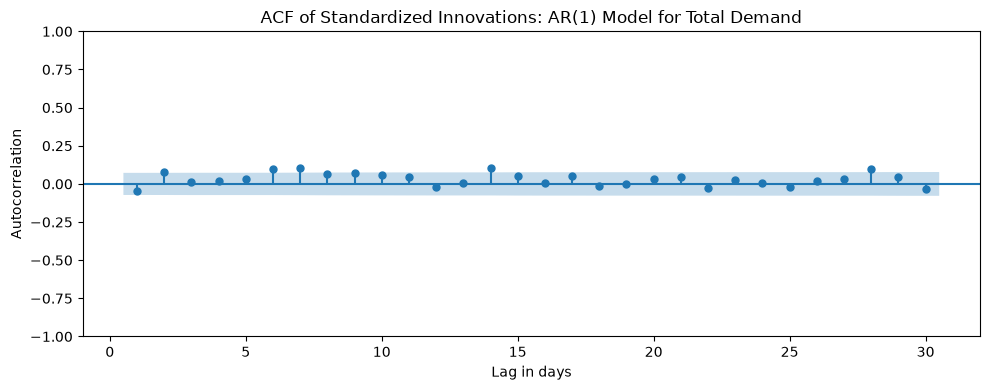

In [26]:
fig, ax = plt.subplots(figsize=(10, 4))

plot_acf(
    cnt_ar1_innovations,
    lags=30,
    alpha=0.05,
    zero=False,
    ax=ax
)

ax.set_title(
    "ACF of Standardized Innovations: AR(1) Model for Total Demand"
)
ax.set_xlabel("Lag in days")
ax.set_ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

## 9. Daily and weekly autoregressive error structure

The AR(1) model removed most first-order serial correlation, but the residual
ACF indicates remaining dependence around weekly lags.

A second candidate model therefore combines:

- a non-seasonal AR(1) component for day-to-day dependence;
- a seasonal AR(1) component with a seven-day period for weekly dependence.

The response variable and explanatory variables remain unchanged.

In [27]:
weekly_ar1_cnt_model = ARIMA(
    endog=y_cnt_ts,
    exog=x_cnt_ts,
    order=(1, 0, 0),
    seasonal_order=(1, 0, 0, 7),
    trend="n",
    enforce_stationarity=True
)

weekly_ar1_cnt = weekly_ar1_cnt_model.fit()

c:\Users\A.GH\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [28]:
print(
    "converged:",
    weekly_ar1_cnt.mle_retvals.get("converged")
)

print(
    "iterations:",
    weekly_ar1_cnt.mle_retvals.get("iterations")
)

print(
    "warnflag:",
    weekly_ar1_cnt.mle_retvals.get("warnflag")
)

converged: False
iterations: 50
warnflag: 1


In [29]:
print("model parameters:")

for parameter_name in weekly_ar1_cnt.param_names:
    print("-", parameter_name)

model parameters:
- Intercept
- C(yr, Sum)[S.0]
- C(season_label, Sum)[S.spring]
- C(season_label, Sum)[S.summer]
- C(season_label, Sum)[S.fall]
- C(workingday, Sum)[S.0]
- C(weather_label, Sum)[S.clear_or_partly_cloudy]
- C(weather_label, Sum)[S.light_rain_or_snow]
- temp_c
- humidity_pct
- windspeed_original_scale
- ar.L1
- ar.S.L7
- sigma2


In [30]:
weekly_ar1_cnt_params = pd.Series(
    np.asarray(weekly_ar1_cnt.params),
    index=weekly_ar1_cnt.param_names
)

weekly_ar1_cnt_metrics = pd.Series({
    "n_obs": int(weekly_ar1_cnt.nobs),
    "log_likelihood": weekly_ar1_cnt.llf,
    "aic": weekly_ar1_cnt.aic,
    "bic": weekly_ar1_cnt.bic,
    "daily_ar1_parameter": weekly_ar1_cnt_params.get(
        "ar.L1",
        np.nan
    ),
    "weekly_ar1_parameter": weekly_ar1_cnt_params.get(
        "ar.S.L7",
        np.nan
    ),
    "innovation_variance": weekly_ar1_cnt_params.get(
        "sigma2",
        np.nan
    )
})

weekly_ar1_cnt_metrics

n_obs                      731.000000
log_likelihood           -5845.365394
aic                      11718.730788
bic                      11783.052577
daily_ar1_parameter          0.459586
weekly_ar1_parameter         0.109905
innovation_variance     517519.431086
dtype: float64

In [31]:
cnt_time_model_comparison = pd.DataFrame({
    "ar1": {
        "log_likelihood": ar1_cnt.llf,
        "aic": ar1_cnt.aic,
        "bic": ar1_cnt.bic
    },
    "ar1_plus_weekly_ar1": {
        "log_likelihood": weekly_ar1_cnt.llf,
        "aic": weekly_ar1_cnt.aic,
        "bic": weekly_ar1_cnt.bic
    }
}).T

cnt_time_model_comparison.round(3)

,log_likelihood,aic,bic
ar1,-5849.309,11724.618,11784.345
ar1_plus_weekly_ar1,-5845.365,11718.731,11783.053


In [32]:
weekly_ar1_cnt_retry = weekly_ar1_cnt_model.fit(
    start_params=weekly_ar1_cnt.params,
    method="statespace",
    method_kwargs={
        "method": "lbfgs",
        "maxiter": 500,
        "disp": False
    }
)

In [33]:
print(
    "converged:",
    weekly_ar1_cnt_retry.mle_retvals.get("converged")
)

print(
    "iterations:",
    weekly_ar1_cnt_retry.mle_retvals.get("iterations")
)

print(
    "warnflag:",
    weekly_ar1_cnt_retry.mle_retvals.get("warnflag")
)

converged: True
iterations: 18
warnflag: 0


In [34]:
weekly_ar1_cnt_retry_params = pd.Series(
    np.asarray(weekly_ar1_cnt_retry.params),
    index=weekly_ar1_cnt_retry.param_names
)

weekly_ar1_cnt_retry_metrics = pd.Series({
    "n_obs": int(weekly_ar1_cnt_retry.nobs),
    "log_likelihood": weekly_ar1_cnt_retry.llf,
    "aic": weekly_ar1_cnt_retry.aic,
    "bic": weekly_ar1_cnt_retry.bic,
    "daily_ar1_parameter": weekly_ar1_cnt_retry_params.get(
        "ar.L1",
        np.nan
    ),
    "weekly_ar1_parameter": weekly_ar1_cnt_retry_params.get(
        "ar.S.L7",
        np.nan
    ),
    "innovation_variance": weekly_ar1_cnt_retry_params.get(
        "sigma2",
        np.nan
    )
})

weekly_ar1_cnt_retry_metrics

n_obs                      731.000000
log_likelihood           -5845.297109
aic                      11718.594218
bic                      11782.916006
daily_ar1_parameter          0.461149
weekly_ar1_parameter         0.110926
innovation_variance     517434.767807
dtype: float64

In [35]:
cnt_time_model_comparison_retry = pd.DataFrame({
    "ar1": {
        "converged": True,
        "log_likelihood": ar1_cnt.llf,
        "aic": ar1_cnt.aic,
        "bic": ar1_cnt.bic
    },
    "ar1_plus_weekly_ar1": {
        "converged": weekly_ar1_cnt_retry.mle_retvals.get(
            "converged"
        ),
        "log_likelihood": weekly_ar1_cnt_retry.llf,
        "aic": weekly_ar1_cnt_retry.aic,
        "bic": weekly_ar1_cnt_retry.bic
    }
}).T

cnt_time_model_comparison_retry.round(3)

,converged,log_likelihood,aic,bic
ar1,True,-5849.308779,11724.617558,11784.344933
ar1_plus_weekly_ar1,True,-5845.297109,11718.594218,11782.916006


## 10. Validation of the daily and weekly AR model

The daily and weekly autoregressive model converged successfully.

Before selecting it as the preferred model, the analysis evaluates:

- statistical uncertainty around the daily and weekly AR parameters;
- remaining lag-1 and lag-7 residual correlation;
- Durbin–Watson statistic;
- Ljung–Box tests at weekly and monthly horizons.

In [36]:
weekly_param_names = weekly_ar1_cnt_retry.param_names

weekly_params = pd.Series(
    np.asarray(weekly_ar1_cnt_retry.params),
    index=weekly_param_names
)

weekly_standard_errors = pd.Series(
    np.asarray(weekly_ar1_cnt_retry.bse),
    index=weekly_param_names
)

weekly_p_values = pd.Series(
    np.asarray(weekly_ar1_cnt_retry.pvalues),
    index=weekly_param_names
)

weekly_confidence_intervals = pd.DataFrame(
    np.asarray(weekly_ar1_cnt_retry.conf_int()),
    index=weekly_param_names,
    columns=["ci_lower", "ci_upper"]
)

weekly_ar1_cnt_parameter_table = pd.DataFrame({
    "estimate": weekly_params,
    "std_error": weekly_standard_errors,
    "p_value": weekly_p_values,
    "ci_lower": weekly_confidence_intervals["ci_lower"],
    "ci_upper": weekly_confidence_intervals["ci_upper"]
})

weekly_ar1_cnt_parameter_table.loc[
    ["ar.L1", "ar.S.L7", "sigma2"]
].round(4)

,estimate,std_error,p_value,ci_lower,ci_upper
ar.L1,0.4611,0.0246,0.0000,0.4130,0.5093
ar.S.L7,0.1109,0.0327,0.0007,0.0469,0.1750
sigma2,517434.7678,20039.9221,0.0000,478157.2421,556712.2935


In [37]:
cnt_weekly_innovations = pd.Series(
    weekly_ar1_cnt_retry
    .filter_results
    .standardized_forecasts_error[0],
    index=y_cnt_ts.index,
    name="standardized_innovation"
)

burn_in = weekly_ar1_cnt_retry.loglikelihood_burn

if burn_in > 0:
    cnt_weekly_innovations = cnt_weekly_innovations.iloc[burn_in:]

cnt_weekly_innovations = (
    cnt_weekly_innovations
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

print("burn-in observations removed:", burn_in)
print("usable innovations:", len(cnt_weekly_innovations))

burn-in observations removed: 0
usable innovations: 731


In [38]:
cnt_weekly_residual_metrics = pd.Series({
    "mean": cnt_weekly_innovations.mean(),
    "standard_deviation": cnt_weekly_innovations.std(),
    "lag1_autocorrelation": (
        cnt_weekly_innovations.autocorr(lag=1)
    ),
    "lag7_autocorrelation": (
        cnt_weekly_innovations.autocorr(lag=7)
    ),
    "durbin_watson": durbin_watson(
        cnt_weekly_innovations
    )
})

cnt_weekly_residual_metrics

mean                    0.011854
standard_deviation      0.999434
lag1_autocorrelation   -0.042847
lag7_autocorrelation   -0.010063
durbin_watson           2.084702
dtype: float64

In [39]:
cnt_weekly_ljung_box = acorr_ljungbox(
    cnt_weekly_innovations,
    lags=[7, 14, 30],
    model_df=2,
    return_df=True
)

cnt_weekly_ljung_box

,lb_stat,lb_pvalue
7,14.713659,0.011659
14,32.556064,0.001135
30,50.498379,0.005687


In [40]:
cnt_time_residual_comparison = pd.DataFrame({
    "ar1": {
        "lag1_autocorrelation": (
            cnt_ar1_innovations.autocorr(lag=1)
        ),
        "lag7_autocorrelation": (
            cnt_ar1_innovations.autocorr(lag=7)
        ),
        "durbin_watson": durbin_watson(
            cnt_ar1_innovations
        )
    },
    "ar1_plus_weekly_ar1": {
        "lag1_autocorrelation": (
            cnt_weekly_innovations.autocorr(lag=1)
        ),
        "lag7_autocorrelation": (
            cnt_weekly_innovations.autocorr(lag=7)
        ),
        "durbin_watson": durbin_watson(
            cnt_weekly_innovations
        )
    }
}).T

cnt_time_residual_comparison.round(4)

,lag1_autocorrelation,lag7_autocorrelation,durbin_watson
ar1,-0.0475,0.1032,2.0944
ar1_plus_weekly_ar1,-0.0428,-0.0101,2.0847


## 11. Remaining autocorrelation after the daily-weekly model

The daily and weekly autoregressive terms removed most of the dependence at
lags 1 and 7. However, the Ljung–Box tests remain statistically significant.

The residual ACF is examined to identify the specific remaining lags before
considering any additional model complexity.

In [41]:
cnt_weekly_acf_values = acf(
    cnt_weekly_innovations,
    nlags=30,
    fft=False
)

cnt_weekly_acf_table = pd.DataFrame({
    "lag": range(1, 31),
    "autocorrelation": cnt_weekly_acf_values[1:]
})

acf_threshold = 1.96 / np.sqrt(len(cnt_weekly_innovations))

cnt_weekly_acf_table["significant"] = (
    cnt_weekly_acf_table["autocorrelation"].abs()
    > acf_threshold
)

print("approximate 95% threshold:", round(acf_threshold, 4))

approximate 95% threshold: 0.0725


In [42]:
cnt_weekly_significant_lags = (
    cnt_weekly_acf_table
    .loc[cnt_weekly_acf_table["significant"]]
    .reset_index(drop=True)
)

cnt_weekly_significant_lags.round(4)

,lag,autocorrelation,significant
0,2,0.0761,True
1,6,0.1043,True
2,14,0.0931,True
3,28,0.0870,True


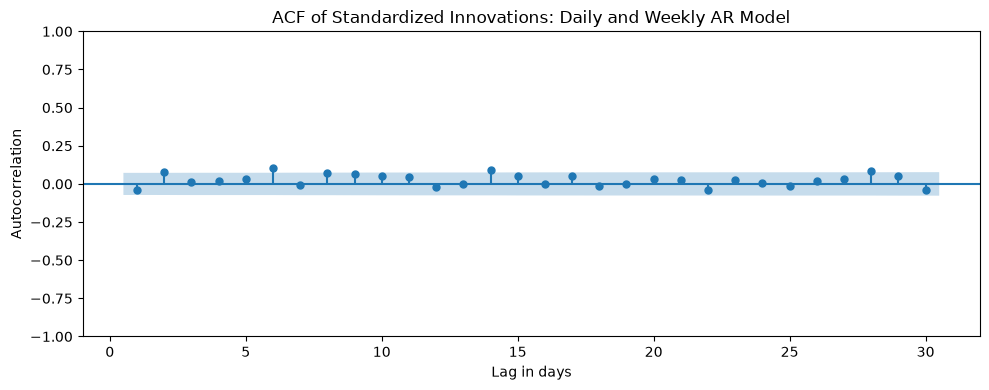

In [43]:
fig, ax = plt.subplots(figsize=(10, 4))

plot_acf(
    cnt_weekly_innovations,
    lags=30,
    alpha=0.05,
    zero=False,
    ax=ax
)

ax.set_title(
    "ACF of Standardized Innovations: Daily and Weekly AR Model"
)
ax.set_xlabel("Lag in days")
ax.set_ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

## 12. Calendar-enhanced daily and weekly AR model

The previous model accounted for working-day status using a single binary
variable. However, residual dependence remained at several calendar-related
lags.

This sensitivity model replaces `workingday` with:

- day of the week;
- holiday status.

The daily AR(1) and weekly seasonal AR(1) error structure is retained.

The purpose is to determine whether remaining weekly dependence reflects an
omitted calendar pattern rather than a need for a more complex autoregressive
error process.

In [44]:
weekday_levels = [0, 1, 2, 3, 4, 5, 6]
holiday_levels = [0, 1]

assert set(day["weekday"].dropna().unique()) == set(
    weekday_levels
)

assert set(day["holiday"].dropna().unique()) == set(
    holiday_levels
)

day["weekday"] = pd.Categorical(
    day["weekday"],
    categories=weekday_levels
)

day["holiday"] = pd.Categorical(
    day["holiday"],
    categories=holiday_levels
)

print("weekday categories:",
      list(day["weekday"].cat.categories))

print("holiday categories:",
      list(day["holiday"].cat.categories))

weekday categories: [0, 1, 2, 3, 4, 5, 6]
holiday categories: [0, 1]


In [45]:
cnt_calendar_formula = (
    "cnt ~ "
    "C(yr, Sum) + "
    "C(season_label, Sum) + "
    "C(weekday, Sum) + "
    "C(holiday, Sum) + "
    "C(weather_label, Sum) + "
    "temp_c + "
    "humidity_pct + "
    "windspeed_original_scale"
)

print(cnt_calendar_formula)

cnt ~ C(yr, Sum) + C(season_label, Sum) + C(weekday, Sum) + C(holiday, Sum) + C(weather_label, Sum) + temp_c + humidity_pct + windspeed_original_scale


In [46]:
y_cnt_calendar, x_cnt_calendar = dmatrices(
    cnt_calendar_formula,
    data=day,
    return_type="dataframe"
)

y_cnt_calendar = y_cnt_calendar.iloc[:, 0]

y_cnt_calendar.index = time_index
x_cnt_calendar.index = time_index

print("response shape:",
      y_cnt_calendar.shape)

print("design matrix shape:",
      x_cnt_calendar.shape)

print("\ndesign matrix columns:")

for column in x_cnt_calendar.columns:
    print("-", column)

response shape: (731,)
design matrix shape: (731, 17)

design matrix columns:
- Intercept
- C(yr, Sum)[S.0]
- C(season_label, Sum)[S.spring]
- C(season_label, Sum)[S.summer]
- C(season_label, Sum)[S.fall]
- C(weekday, Sum)[S.0]
- C(weekday, Sum)[S.1]
- C(weekday, Sum)[S.2]
- C(weekday, Sum)[S.3]
- C(weekday, Sum)[S.4]
- C(weekday, Sum)[S.5]
- C(holiday, Sum)[S.0]
- C(weather_label, Sum)[S.clear_or_partly_cloudy]
- C(weather_label, Sum)[S.light_rain_or_snow]
- temp_c
- humidity_pct
- windspeed_original_scale


In [47]:
cnt_calendar_model = ARIMA(
    endog=y_cnt_calendar,
    exog=x_cnt_calendar,
    order=(1, 0, 0),
    seasonal_order=(1, 0, 0, 7),
    trend="n",
    enforce_stationarity=True
)

cnt_calendar = cnt_calendar_model.fit(
    method="statespace",
    method_kwargs={
        "method": "lbfgs",
        "maxiter": 500,
        "disp": False
    }
)

In [48]:
print(
    "converged:",
    cnt_calendar.mle_retvals.get("converged")
)

print(
    "iterations:",
    cnt_calendar.mle_retvals.get("iterations")
)

print(
    "warnflag:",
    cnt_calendar.mle_retvals.get("warnflag")
)

converged: True
iterations: 21
warnflag: 0


In [49]:
cnt_calendar_model_comparison = pd.DataFrame({
    "workingday_model": {
        "n_parameters": len(
            weekly_ar1_cnt_retry.params
        ),
        "log_likelihood": weekly_ar1_cnt_retry.llf,
        "aic": weekly_ar1_cnt_retry.aic,
        "bic": weekly_ar1_cnt_retry.bic
    },
    "weekday_holiday_model": {
        "n_parameters": len(
            cnt_calendar.params
        ),
        "log_likelihood": cnt_calendar.llf,
        "aic": cnt_calendar.aic,
        "bic": cnt_calendar.bic
    }
}).T

cnt_calendar_model_comparison.round(3)

,n_parameters,log_likelihood,aic,bic
workingday_model,14.0,-5845.297,11718.594,11782.916
weekday_holiday_model,20.0,-5833.136,11706.272,11798.160


In [50]:
cnt_calendar_innovations = pd.Series(
    cnt_calendar
    .filter_results
    .standardized_forecasts_error[0],
    index=y_cnt_calendar.index,
    name="standardized_innovation"
)

calendar_burn_in = cnt_calendar.loglikelihood_burn

if calendar_burn_in > 0:
    cnt_calendar_innovations = (
        cnt_calendar_innovations.iloc[
            calendar_burn_in:
        ]
    )

cnt_calendar_innovations = (
    cnt_calendar_innovations
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

print("usable innovations:",
      len(cnt_calendar_innovations))

usable innovations: 731


In [51]:
cnt_calendar_ljung_box = acorr_ljungbox(
    cnt_calendar_innovations,
    lags=[7, 14, 30],
    model_df=2,
    return_df=True
)

cnt_calendar_residual_comparison = pd.DataFrame({
    "workingday_model": {
        "lag1_autocorrelation":
            cnt_weekly_innovations.autocorr(lag=1),

        "lag7_autocorrelation":
            cnt_weekly_innovations.autocorr(lag=7),

        "durbin_watson":
            durbin_watson(cnt_weekly_innovations),

        "ljung_box_pvalue_7":
            cnt_weekly_ljung_box.loc[7, "lb_pvalue"],

        "ljung_box_pvalue_14":
            cnt_weekly_ljung_box.loc[14, "lb_pvalue"],

        "ljung_box_pvalue_30":
            cnt_weekly_ljung_box.loc[30, "lb_pvalue"]
    },

    "weekday_holiday_model": {
        "lag1_autocorrelation":
            cnt_calendar_innovations.autocorr(lag=1),

        "lag7_autocorrelation":
            cnt_calendar_innovations.autocorr(lag=7),

        "durbin_watson":
            durbin_watson(cnt_calendar_innovations),

        "ljung_box_pvalue_7":
            cnt_calendar_ljung_box.loc[7, "lb_pvalue"],

        "ljung_box_pvalue_14":
            cnt_calendar_ljung_box.loc[14, "lb_pvalue"],

        "ljung_box_pvalue_30":
            cnt_calendar_ljung_box.loc[30, "lb_pvalue"]
    }
}).T

cnt_calendar_residual_comparison.round(4)

,lag1_autocorrelation,lag7_autocorrelation,durbin_watson,ljung_box_pvalue_7,ljung_box_pvalue_14,ljung_box_pvalue_30
workingday_model,-0.0428,-0.0101,2.0847,0.0117,0.0011,0.0057
weekday_holiday_model,-0.0508,-0.0031,2.1000,0.0017,0.0002,0.0020


## 13. Preferred model for total daily demand

The preferred model for `cnt` retains the original working-day specification
and combines daily and weekly autoregressive errors.

Selected specification:

- Fixed effects: year, season, working-day status, weather category,
  temperature, humidity, and windspeed.
- Error structure: non-seasonal AR(1) and seasonal AR(1) with a seven-day period.

The alternative weekday-and-holiday model improved AIC but produced a worse BIC
and did not improve residual autocorrelation diagnostics. The simpler
working-day model was therefore retained.

The selected model substantially reduced lag-1 and lag-7 residual correlation.
Some small residual dependence remains according to the Ljung–Box tests and is
reported as a model limitation.

In [52]:
cnt_preferred_model = weekly_ar1_cnt_retry
cnt_preferred_innovations = cnt_weekly_innovations

cnt_model_decision = pd.Series({
    "response": "cnt",
    "selected_fixed_effects": "workingday specification",
    "selected_error_structure": "AR(1) + seasonal AR(1), period 7",
    "converged": cnt_preferred_model.mle_retvals.get("converged"),
    "aic": cnt_preferred_model.aic,
    "bic": cnt_preferred_model.bic,
    "daily_ar1_parameter": weekly_params["ar.L1"],
    "weekly_ar1_parameter": weekly_params["ar.S.L7"],
    "lag1_autocorrelation": (
        cnt_preferred_innovations.autocorr(lag=1)
    ),
    "lag7_autocorrelation": (
        cnt_preferred_innovations.autocorr(lag=7)
    ),
    "durbin_watson": durbin_watson(
        cnt_preferred_innovations
    ),
    "ljung_box_pvalue_7": (
        cnt_weekly_ljung_box.loc[7, "lb_pvalue"]
    ),
    "ljung_box_pvalue_14": (
        cnt_weekly_ljung_box.loc[14, "lb_pvalue"]
    ),
    "ljung_box_pvalue_30": (
        cnt_weekly_ljung_box.loc[30, "lb_pvalue"]
    )
})

cnt_model_decision

response                                                 cnt
selected_fixed_effects              workingday specification
selected_error_structure    AR(1) + seasonal AR(1), period 7
converged                                               True
aic                                             11718.594218
bic                                             11782.916006
daily_ar1_parameter                                 0.461149
weekly_ar1_parameter                                0.110926
lag1_autocorrelation                               -0.042847
lag7_autocorrelation                               -0.010063
durbin_watson                                       2.084702
ljung_box_pvalue_7                                  0.011659
ljung_box_pvalue_14                                 0.001135
ljung_box_pvalue_30                                 0.005687
dtype: object

## 14. Reusable time-series modeling workflow

The same candidate error structures are evaluated separately for casual and
registered users.

For each response, the workflow estimates:

1. an OLS baseline;
2. a regression with AR(1) errors;
3. a regression with daily AR(1) and weekly seasonal AR(1) errors.

The preferred model is selected separately for each user segment rather than
assuming that both segments have the same temporal structure.

In [53]:
def extract_standardized_innovations(result, index):
    """Extract finite standardized one-step-ahead forecast errors."""

    innovations = pd.Series(
        np.asarray(
            result
            .filter_results
            .standardized_forecasts_error[0]
        ),
        index=index,
        name="standardized_innovation"
    )

    burn_in = int(result.loglikelihood_burn or 0)

    if burn_in > 0:
        innovations = innovations.iloc[burn_in:]

    innovations = (
        innovations
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    return innovations

In [54]:
def fit_response_time_models(
    response,
    data,
    design_matrix,
    time_index
):
    """Fit OLS, AR(1), and daily-plus-weekly AR models."""

    y = pd.Series(
        data[response].to_numpy(dtype=float),
        index=time_index,
        name=response
    )

    x = design_matrix.copy()
    x.index = time_index

    # OLS baseline
    ols_result = sm.OLS(
        endog=y,
        exog=x
    ).fit()

    # Daily AR(1)
    ar1_model = ARIMA(
        endog=y,
        exog=x,
        order=(1, 0, 0),
        trend="n",
        enforce_stationarity=True
    )

    ar1_result = ar1_model.fit(
        method="statespace",
        method_kwargs={
            "method": "lbfgs",
            "maxiter": 500,
            "disp": False
        }
    )

    # Daily AR(1) plus weekly seasonal AR(1)
    weekly_model = ARIMA(
        endog=y,
        exog=x,
        order=(1, 0, 0),
        seasonal_order=(1, 0, 0, 7),
        trend="n",
        enforce_stationarity=True
    )

    weekly_result = weekly_model.fit(
        method="statespace",
        method_kwargs={
            "method": "lbfgs",
            "maxiter": 500,
            "disp": False
        }
    )

    ar1_innovations = extract_standardized_innovations(
        ar1_result,
        time_index
    )

    weekly_innovations = extract_standardized_innovations(
        weekly_result,
        time_index
    )

    ar1_ljung_box = acorr_ljungbox(
        ar1_innovations,
        lags=[7, 14, 30],
        model_df=1,
        return_df=True
    )

    weekly_ljung_box = acorr_ljungbox(
        weekly_innovations,
        lags=[7, 14, 30],
        model_df=2,
        return_df=True
    )

    ar1_params = pd.Series(
        np.asarray(ar1_result.params),
        index=ar1_result.param_names
    )

    weekly_params = pd.Series(
        np.asarray(weekly_result.params),
        index=weekly_result.param_names
    )

    comparison = pd.DataFrame({
        "ar1": {
            "converged":
                ar1_result.mle_retvals.get("converged"),

            "aic":
                ar1_result.aic,

            "bic":
                ar1_result.bic,

            "daily_ar1_parameter":
                ar1_params.get("ar.L1", np.nan),

            "weekly_ar1_parameter":
                np.nan,

            "lag1_autocorrelation":
                ar1_innovations.autocorr(lag=1),

            "lag7_autocorrelation":
                ar1_innovations.autocorr(lag=7),

            "durbin_watson":
                durbin_watson(ar1_innovations),

            "ljung_box_pvalue_7":
                ar1_ljung_box.loc[7, "lb_pvalue"],

            "ljung_box_pvalue_14":
                ar1_ljung_box.loc[14, "lb_pvalue"],

            "ljung_box_pvalue_30":
                ar1_ljung_box.loc[30, "lb_pvalue"]
        },

        "ar1_plus_weekly_ar1": {
            "converged":
                weekly_result.mle_retvals.get("converged"),

            "aic":
                weekly_result.aic,

            "bic":
                weekly_result.bic,

            "daily_ar1_parameter":
                weekly_params.get("ar.L1", np.nan),

            "weekly_ar1_parameter":
                weekly_params.get("ar.S.L7", np.nan),

            "lag1_autocorrelation":
                weekly_innovations.autocorr(lag=1),

            "lag7_autocorrelation":
                weekly_innovations.autocorr(lag=7),

            "durbin_watson":
                durbin_watson(weekly_innovations),

            "ljung_box_pvalue_7":
                weekly_ljung_box.loc[7, "lb_pvalue"],

            "ljung_box_pvalue_14":
                weekly_ljung_box.loc[14, "lb_pvalue"],

            "ljung_box_pvalue_30":
                weekly_ljung_box.loc[30, "lb_pvalue"]
        }
    }).T

    return {
        "response": response,
        "y": y,
        "x": x,
        "ols": ols_result,
        "ar1": ar1_result,
        "weekly": weekly_result,
        "ar1_innovations": ar1_innovations,
        "weekly_innovations": weekly_innovations,
        "ar1_ljung_box": ar1_ljung_box,
        "weekly_ljung_box": weekly_ljung_box,
        "comparison": comparison
    }

In [55]:
casual_results = fit_response_time_models(
    response="casual",
    data=day,
    design_matrix=x_cnt_ts,
    time_index=time_index
)

In [56]:
casual_results["comparison"].round(4)

,converged,aic,bic,daily_ar1_parameter,weekly_ar1_parameter,lag1_autocorrelation,lag7_autocorrelation,durbin_watson,ljung_box_pvalue_7,ljung_box_pvalue_14,ljung_box_pvalue_30
ar1,True,10632.133216,10691.860591,0.398523,NaN,0.038548,0.269208,1.918572,0.0,0.0,0.0
ar1_plus_weekly_ar1,True,10573.596794,10637.918582,0.330725,0.302277,0.009262,-0.05677,1.978613,0.0,0.0,0.0


In [57]:
casual_weekly_model = casual_results["weekly"]

casual_param_names = casual_weekly_model.param_names

casual_params = pd.Series(
    np.asarray(casual_weekly_model.params),
    index=casual_param_names
)

casual_standard_errors = pd.Series(
    np.asarray(casual_weekly_model.bse),
    index=casual_param_names
)

casual_p_values = pd.Series(
    np.asarray(casual_weekly_model.pvalues),
    index=casual_param_names
)

casual_confidence_intervals = pd.DataFrame(
    np.asarray(casual_weekly_model.conf_int()),
    index=casual_param_names,
    columns=["ci_lower", "ci_upper"]
)

casual_time_parameter_table = pd.DataFrame({
    "estimate": casual_params,
    "std_error": casual_standard_errors,
    "p_value": casual_p_values,
    "ci_lower": casual_confidence_intervals["ci_lower"],
    "ci_upper": casual_confidence_intervals["ci_upper"]
})

casual_time_parameter_table.loc[
    ["ar.L1", "ar.S.L7", "sigma2"]
].round(4)

,estimate,std_error,p_value,ci_lower,ci_upper
ar.L1,0.3307,0.0280,0.0,0.2758,0.3857
ar.S.L7,0.3023,0.0258,0.0,0.2518,0.3528
sigma2,107717.0917,4116.0680,0.0,99649.7466,115784.4368


In [58]:
casual_weekly_innovations = casual_results[
    "weekly_innovations"
]

casual_weekly_acf_values = acf(
    casual_weekly_innovations,
    nlags=30,
    fft=False
)

casual_weekly_acf_table = pd.DataFrame({
    "lag": range(1, 31),
    "autocorrelation": casual_weekly_acf_values[1:]
})

casual_acf_threshold = (
    1.96 / np.sqrt(len(casual_weekly_innovations))
)

casual_weekly_acf_table["outside_approximate_limit"] = (
    casual_weekly_acf_table["autocorrelation"].abs()
    > casual_acf_threshold
)

print(
    "approximate 95% threshold:",
    round(casual_acf_threshold, 4)
)

casual_significant_lags = (
    casual_weekly_acf_table
    .loc[
        casual_weekly_acf_table[
            "outside_approximate_limit"
        ]
    ]
    .reset_index(drop=True)
)

casual_significant_lags.round(4)

approximate 95% threshold: 0.0725


,lag,autocorrelation,outside_approximate_limit
0,5,-0.0774,True
1,6,0.2047,True
2,8,0.1009,True
3,14,0.1235,True
4,15,0.0822,True
5,18,-0.0832,True
6,20,0.0899,True
7,21,0.1629,True
8,24,-0.1190,True
9,28,0.1350,True


## 15. Calendar sensitivity model for casual demand

Casual-user residuals retain noticeable weekly and multi-week dependence after
including daily and weekly autoregressive errors.

Because casual demand may differ across individual days of the week, this
sensitivity model replaces the binary working-day variable with:

- weekday;
- holiday status.

The daily AR(1) and weekly seasonal AR(1) error structure remains unchanged.

In [59]:
y_casual_calendar = pd.Series(
    day["casual"].to_numpy(dtype=float),
    index=time_index,
    name="casual"
)

x_casual_calendar = x_cnt_calendar.copy()
x_casual_calendar.index = time_index

print("response shape:", y_casual_calendar.shape)
print("design matrix shape:", x_casual_calendar.shape)

response shape: (731,)
design matrix shape: (731, 17)


In [60]:
casual_calendar_model = ARIMA(
    endog=y_casual_calendar,
    exog=x_casual_calendar,
    order=(1, 0, 0),
    seasonal_order=(1, 0, 0, 7),
    trend="n",
    enforce_stationarity=True
)

casual_calendar = casual_calendar_model.fit(
    method="statespace",
    method_kwargs={
        "method": "lbfgs",
        "maxiter": 500,
        "disp": False
    }
)

In [61]:
print(
    "converged:",
    casual_calendar.mle_retvals.get("converged")
)

print(
    "iterations:",
    casual_calendar.mle_retvals.get("iterations")
)

print(
    "warnflag:",
    casual_calendar.mle_retvals.get("warnflag")
)

converged: True
iterations: 149
warnflag: 0


In [62]:
casual_calendar_model_comparison = pd.DataFrame({
    "workingday_model": {
        "n_parameters": len(
            casual_results["weekly"].params
        ),
        "log_likelihood": casual_results["weekly"].llf,
        "aic": casual_results["weekly"].aic,
        "bic": casual_results["weekly"].bic
    },
    "weekday_holiday_model": {
        "n_parameters": len(
            casual_calendar.params
        ),
        "log_likelihood": casual_calendar.llf,
        "aic": casual_calendar.aic,
        "bic": casual_calendar.bic
    }
}).T

casual_calendar_model_comparison.round(3)

,n_parameters,log_likelihood,aic,bic
workingday_model,14.0,-5272.798,10573.597,10637.919
weekday_holiday_model,20.0,-5250.706,10541.413,10633.301


In [63]:
casual_calendar_innovations = (
    extract_standardized_innovations(
        casual_calendar,
        time_index
    )
)

print(
    "usable innovations:",
    len(casual_calendar_innovations)
)

usable innovations: 731


In [64]:
casual_calendar_ljung_box = acorr_ljungbox(
    casual_calendar_innovations,
    lags=[7, 14, 30],
    model_df=2,
    return_df=True
)

casual_calendar_ljung_box

,lb_stat,lb_pvalue
7,41.858239,6.292571e-08
14,59.697175,2.563143e-08
30,141.606162,3.921857e-17


In [65]:
casual_calendar_residual_comparison = pd.DataFrame({
    "workingday_model": {
        "lag1_autocorrelation":
            casual_results[
                "weekly_innovations"
            ].autocorr(lag=1),

        "lag7_autocorrelation":
            casual_results[
                "weekly_innovations"
            ].autocorr(lag=7),

        "durbin_watson":
            durbin_watson(
                casual_results[
                    "weekly_innovations"
                ]
            ),

        "ljung_box_pvalue_7":
            casual_results[
                "weekly_ljung_box"
            ].loc[7, "lb_pvalue"],

        "ljung_box_pvalue_14":
            casual_results[
                "weekly_ljung_box"
            ].loc[14, "lb_pvalue"],

        "ljung_box_pvalue_30":
            casual_results[
                "weekly_ljung_box"
            ].loc[30, "lb_pvalue"]
    },

    "weekday_holiday_model": {
        "lag1_autocorrelation":
            casual_calendar_innovations.autocorr(lag=1),

        "lag7_autocorrelation":
            casual_calendar_innovations.autocorr(lag=7),

        "durbin_watson":
            durbin_watson(
                casual_calendar_innovations
            ),

        "ljung_box_pvalue_7":
            casual_calendar_ljung_box.loc[
                7,
                "lb_pvalue"
            ],

        "ljung_box_pvalue_14":
            casual_calendar_ljung_box.loc[
                14,
                "lb_pvalue"
            ],

        "ljung_box_pvalue_30":
            casual_calendar_ljung_box.loc[
                30,
                "lb_pvalue"
            ]
    }
}).T

casual_calendar_residual_comparison.round(4)

,lag1_autocorrelation,lag7_autocorrelation,durbin_watson,ljung_box_pvalue_7,ljung_box_pvalue_14,ljung_box_pvalue_30
workingday_model,0.0093,-0.0568,1.9786,0.0,0.0,0.0
weekday_holiday_model,0.0124,-0.0416,1.9702,0.0,0.0,0.0


## 16. Preferred model for casual-user demand

The preferred model for `casual` demand uses individual weekday and holiday
effects together with daily and weekly autoregressive errors.

Selected specification:

- Fixed effects: year, season, weekday, holiday, weather category,
  temperature, humidity, and windspeed.
- Error structure: non-seasonal AR(1) and seasonal AR(1) with a
  seven-day period.

Compared with the simpler working-day specification, the calendar-enhanced
model produced lower AIC and BIC values. Residual lag-1 and lag-7 correlations
were small in both models.

The Ljung–Box tests remained statistically significant, indicating that some
small residual temporal dependence remains. No additional AR or MA terms were
added in order to preserve model interpretability and avoid overfitting.

In [66]:
casual_preferred_model = casual_calendar

casual_preferred_innovations = (
    casual_calendar_innovations
)

casual_preferred_params = pd.Series(
    np.asarray(casual_preferred_model.params),
    index=casual_preferred_model.param_names
)

casual_model_decision = pd.Series({
    "response": "casual",
    "selected_fixed_effects": "weekday and holiday specification",
    "selected_error_structure": (
        "AR(1) + seasonal AR(1), period 7"
    ),
    "converged": (
        casual_preferred_model
        .mle_retvals
        .get("converged")
    ),
    "aic": casual_preferred_model.aic,
    "bic": casual_preferred_model.bic,
    "daily_ar1_parameter": (
        casual_preferred_params.get(
            "ar.L1",
            np.nan
        )
    ),
    "weekly_ar1_parameter": (
        casual_preferred_params.get(
            "ar.S.L7",
            np.nan
        )
    ),
    "lag1_autocorrelation": (
        casual_preferred_innovations.autocorr(lag=1)
    ),
    "lag7_autocorrelation": (
        casual_preferred_innovations.autocorr(lag=7)
    ),
    "durbin_watson": durbin_watson(
        casual_preferred_innovations
    ),
    "ljung_box_pvalue_7": (
        casual_calendar_ljung_box.loc[
            7,
            "lb_pvalue"
        ]
    ),
    "ljung_box_pvalue_14": (
        casual_calendar_ljung_box.loc[
            14,
            "lb_pvalue"
        ]
    ),
    "ljung_box_pvalue_30": (
        casual_calendar_ljung_box.loc[
            30,
            "lb_pvalue"
        ]
    )
})

casual_model_decision

response                                               casual
selected_fixed_effects      weekday and holiday specification
selected_error_structure     AR(1) + seasonal AR(1), period 7
converged                                                True
aic                                              10541.412964
bic                                              10633.301234
daily_ar1_parameter                                  0.367551
weekly_ar1_parameter                                 0.252348
lag1_autocorrelation                                 0.012385
lag7_autocorrelation                                -0.041584
durbin_watson                                        1.970166
ljung_box_pvalue_7                                        0.0
ljung_box_pvalue_14                                       0.0
ljung_box_pvalue_30                                       0.0
dtype: object

In [67]:
registered_results = fit_response_time_models(
    response="registered",
    data=day,
    design_matrix=x_cnt_ts,
    time_index=time_index
)

In [68]:
registered_results["comparison"].round(4)

,converged,aic,bic,daily_ar1_parameter,weekly_ar1_parameter,lag1_autocorrelation,lag7_autocorrelation,durbin_watson,ljung_box_pvalue_7,ljung_box_pvalue_14,ljung_box_pvalue_30
ar1,True,11320.971577,11380.698952,0.538906,NaN,-0.029046,0.095586,2.05772,0.023133,0.001825,0.004055
ar1_plus_weekly_ar1,True,11318.949079,11383.270867,0.516813,0.101181,-0.025902,-0.012163,2.051317,0.153207,0.016894,0.054345


In [69]:
registered_weekly_model = registered_results["weekly"]

registered_param_names = (
    registered_weekly_model.param_names
)

registered_params = pd.Series(
    np.asarray(registered_weekly_model.params),
    index=registered_param_names
)

registered_standard_errors = pd.Series(
    np.asarray(registered_weekly_model.bse),
    index=registered_param_names
)

registered_p_values = pd.Series(
    np.asarray(registered_weekly_model.pvalues),
    index=registered_param_names
)

registered_confidence_intervals = pd.DataFrame(
    np.asarray(
        registered_weekly_model.conf_int()
    ),
    index=registered_param_names,
    columns=["ci_lower", "ci_upper"]
)

registered_time_parameter_table = pd.DataFrame({
    "estimate": registered_params,
    "std_error": registered_standard_errors,
    "p_value": registered_p_values,
    "ci_lower": (
        registered_confidence_intervals["ci_lower"]
    ),
    "ci_upper": (
        registered_confidence_intervals["ci_upper"]
    )
})

registered_time_parameter_table.loc[
    ["ar.L1", "ar.S.L7", "sigma2"]
].round(4)

,estimate,std_error,p_value,ci_lower,ci_upper
ar.L1,0.5168,0.0227,0.0000,0.4724,0.5612
ar.S.L7,0.1012,0.0384,0.0085,0.0259,0.1765
sigma2,300759.4021,11976.3755,0.0000,277286.1375,324232.6667


## 17. Preferred model for registered-user demand

The preferred model for `registered` demand retains the working-day
specification and includes both daily and weekly autoregressive errors.

Selected specification:

- Fixed effects: year, season, working-day status, weather category,
  temperature, humidity, and windspeed.
- Error structure: non-seasonal AR(1) and seasonal AR(1) with a
  seven-day period.

The weekly autoregressive parameter was statistically significant, although
its magnitude was smaller than that observed for casual users.

The daily-weekly model substantially reduced residual lag-7 correlation and
improved several residual diagnostics. Evidence in favor of the weekly
component was moderate rather than overwhelming because AIC improved slightly
while BIC marginally favored the simpler AR(1) model.

In [70]:
registered_preferred_model = registered_results["weekly"]

registered_preferred_innovations = registered_results[
    "weekly_innovations"
]

registered_preferred_params = pd.Series(
    np.asarray(registered_preferred_model.params),
    index=registered_preferred_model.param_names
)

registered_model_decision = pd.Series({
    "response": "registered",
    "selected_fixed_effects": "workingday specification",
    "selected_error_structure": (
        "AR(1) + seasonal AR(1), period 7"
    ),
    "converged": (
        registered_preferred_model
        .mle_retvals
        .get("converged")
    ),
    "aic": registered_preferred_model.aic,
    "bic": registered_preferred_model.bic,
    "daily_ar1_parameter": (
        registered_preferred_params.get(
            "ar.L1",
            np.nan
        )
    ),
    "weekly_ar1_parameter": (
        registered_preferred_params.get(
            "ar.S.L7",
            np.nan
        )
    ),
    "lag1_autocorrelation": (
        registered_preferred_innovations.autocorr(lag=1)
    ),
    "lag7_autocorrelation": (
        registered_preferred_innovations.autocorr(lag=7)
    ),
    "durbin_watson": durbin_watson(
        registered_preferred_innovations
    ),
    "ljung_box_pvalue_7": (
        registered_results[
            "weekly_ljung_box"
        ].loc[7, "lb_pvalue"]
    ),
    "ljung_box_pvalue_14": (
        registered_results[
            "weekly_ljung_box"
        ].loc[14, "lb_pvalue"]
    ),
    "ljung_box_pvalue_30": (
        registered_results[
            "weekly_ljung_box"
        ].loc[30, "lb_pvalue"]
    )
})

registered_model_decision

response                                          registered
selected_fixed_effects              workingday specification
selected_error_structure    AR(1) + seasonal AR(1), period 7
converged                                               True
aic                                             11318.949079
bic                                             11383.270867
daily_ar1_parameter                                 0.516813
weekly_ar1_parameter                                0.101181
lag1_autocorrelation                               -0.025902
lag7_autocorrelation                               -0.012163
durbin_watson                                       2.051317
ljung_box_pvalue_7                                  0.153207
ljung_box_pvalue_14                                 0.016894
ljung_box_pvalue_30                                 0.054345
dtype: object

In [71]:
preferred_model_summary = pd.DataFrame([
    cnt_model_decision,
    casual_model_decision,
    registered_model_decision
])

preferred_model_summary = (
    preferred_model_summary
    .set_index("response")
)

preferred_model_summary.round(4)

,selected_fixed_effects,selected_error_structure,converged,aic,bic,daily_ar1_parameter,weekly_ar1_parameter,lag1_autocorrelation,lag7_autocorrelation,durbin_watson,ljung_box_pvalue_7,ljung_box_pvalue_14,ljung_box_pvalue_30
response,,,,,,,,,,,,,
cnt,workingday specification,"AR(1) + seasonal AR(1), period 7",True,11718.5942,11782.9160,0.4611,0.1109,-0.0428,-0.0101,2.0847,0.0117,0.0011,0.0057
casual,weekday and holiday specification,"AR(1) + seasonal AR(1), period 7",True,10541.4130,10633.3012,0.3676,0.2523,0.0124,-0.0416,1.9702,0.0000,0.0000,0.0000
registered,workingday specification,"AR(1) + seasonal AR(1), period 7",True,11318.9491,11383.2709,0.5168,0.1012,-0.0259,-0.0122,2.0513,0.1532,0.0169,0.0543


## 18. Final coefficient tables

The preferred models have now been selected separately for total, casual, and
registered demand.

This section extracts coefficient estimates, standard errors, confidence
intervals, and p-values from the selected models.

Categorical predictors use sum coding. Their coefficients therefore represent
deviations from the overall adjusted mean rather than differences from a single
reference category.

In [72]:
def extract_parameter_table(model_result, response):
    """Create a tidy parameter table from a fitted time-series model."""

    parameter_names = model_result.param_names
    confidence_intervals = np.asarray(
        model_result.conf_int()
    )

    parameter_table = pd.DataFrame({
        "response": response,
        "term": parameter_names,
        "estimate": np.asarray(model_result.params),
        "std_error": np.asarray(model_result.bse),
        "p_value": np.asarray(model_result.pvalues),
        "ci_lower": confidence_intervals[:, 0],
        "ci_upper": confidence_intervals[:, 1]
    })

    parameter_table["parameter_type"] = np.select(
        [
            parameter_table["term"].isin(
                ["ar.L1", "ar.S.L7"]
            ),
            parameter_table["term"].eq("sigma2")
        ],
        [
            "time_structure",
            "variance"
        ],
        default="fixed_effect"
    )

    return parameter_table

In [73]:
cnt_parameter_table = extract_parameter_table(
    model_result=cnt_preferred_model,
    response="cnt"
)

cnt_fixed_effects = (
    cnt_parameter_table
    .loc[
        cnt_parameter_table["parameter_type"]
        .eq("fixed_effect")
    ]
    .copy()
)

cnt_fixed_effects["significant_05"] = (
    cnt_fixed_effects["p_value"] < 0.05
)

In [74]:
cnt_fixed_effects_display = cnt_fixed_effects[
    [
        "term",
        "estimate",
        "std_error",
        "p_value",
        "ci_lower",
        "ci_upper",
        "significant_05"
    ]
].copy()

for column in [
    "estimate",
    "std_error",
    "ci_lower",
    "ci_upper"
]:
    cnt_fixed_effects_display[column] = (
        cnt_fixed_effects_display[column].round(4)
    )

cnt_fixed_effects_display["p_value"] = (
    cnt_fixed_effects_display["p_value"]
    .map(lambda value: f"{value:.6g}")
)

cnt_fixed_effects_display

,term,estimate,std_error,p_value,ci_lower,ci_upper,significant_05
0,Intercept,3612.1619,249.8035,2.16748e-47,3122.5561,4101.7677,True
1,"C(yr, Sum)[S.0]",-1004.0610,59.0132,6.44641e-65,-1119.7246,-888.3973,True
2,"C(season_label, Sum)[S.spring]",-888.7404,120.0402,1.32453e-13,-1124.0149,-653.4659,True
3,"C(season_label, Sum)[S.summer]",260.3968,90.5436,0.00402845,82.9345,437.8590,True
4,"C(season_label, Sum)[S.fall]",-26.6466,106.6822,0.802761,-235.7398,182.4466,False
5,"C(workingday, Sum)[S.0]",-81.1134,30.5674,0.00796398,-141.0244,-21.2024,True
6,"C(weather_label, Sum)[S.clear_or_partly_cloudy]",777.5164,61.6271,1.71348e-36,656.7295,898.3034,True
7,"C(weather_label, Sum)[S.light_rain_or_snow]",-1123.5897,77.6659,1.95917e-47,-1275.8120,-971.3674,True
8,temp_c,111.8856,7.5016,2.63699e-50,97.1827,126.5884,True
9,humidity_pct,-16.5910,2.8162,3.83161e-09,-22.1107,-11.0714,True


## 19. Final coefficients for casual-user demand

The preferred casual-demand model includes individual weekday and holiday
effects together with daily and weekly autoregressive errors.

The following table is used to identify which adjusted relationships remain
statistically supported after accounting for temporal dependence.

In [75]:
casual_parameter_table = extract_parameter_table(
    model_result=casual_preferred_model,
    response="casual"
)

casual_fixed_effects = (
    casual_parameter_table
    .loc[
        casual_parameter_table["parameter_type"]
        .eq("fixed_effect")
    ]
    .copy()
)

casual_fixed_effects["significant_05"] = (
    casual_fixed_effects["p_value"] < 0.05
)

casual_fixed_effects_display = casual_fixed_effects[
    [
        "term",
        "estimate",
        "std_error",
        "p_value",
        "ci_lower",
        "ci_upper",
        "significant_05"
    ]
].copy()

for column in [
    "estimate",
    "std_error",
    "ci_lower",
    "ci_upper"
]:
    casual_fixed_effects_display[column] = (
        casual_fixed_effects_display[column].round(4)
    )

casual_fixed_effects_display["p_value"] = (
    casual_fixed_effects_display["p_value"]
    .map(lambda value: f"{value:.6g}")
)

casual_fixed_effects_display

,term,estimate,std_error,p_value,ci_lower,ci_upper,significant_05
0,Intercept,873.4939,111.0394,3.64644e-15,655.8606,1091.1272,True
1,"C(yr, Sum)[S.0]",-138.4870,27.7366,5.9469e-07,-192.8497,-84.1243,True
2,"C(season_label, Sum)[S.spring]",-144.3970,55.8599,0.00973839,-253.8805,-34.9135,True
3,"C(season_label, Sum)[S.summer]",175.4994,39.1469,7.35672e-06,98.7729,252.2259,True
4,"C(season_label, Sum)[S.fall]",-45.0175,52.6829,0.392829,-148.2740,58.2391,False
5,"C(weekday, Sum)[S.0]",511.9066,39.2809,8.05404e-39,434.9173,588.8958,True
6,"C(weekday, Sum)[S.1]",-221.9331,50.7216,1.21144e-05,-321.3456,-122.5207,True
7,"C(weekday, Sum)[S.2]",-284.6216,61.2716,3.39671e-06,-404.7117,-164.5315,True
8,"C(weekday, Sum)[S.3]",-288.1573,58.8368,9.70312e-07,-403.4753,-172.8392,True
9,"C(weekday, Sum)[S.4]",-275.9889,68.4068,5.47125e-05,-410.0637,-141.9141,True


## 20. Final coefficients for registered-user demand

The preferred registered-demand model retains working-day status and includes
daily and weekly autoregressive errors.

The coefficient table is used to compare registered-user behavior with casual
and total demand after accounting for temporal dependence.

In [76]:
registered_parameter_table = extract_parameter_table(
    model_result=registered_preferred_model,
    response="registered"
)

registered_fixed_effects = (
    registered_parameter_table
    .loc[
        registered_parameter_table["parameter_type"]
        .eq("fixed_effect")
    ]
    .copy()
)

registered_fixed_effects["significant_05"] = (
    registered_fixed_effects["p_value"] < 0.05
)

registered_fixed_effects_display = registered_fixed_effects[
    [
        "term",
        "estimate",
        "std_error",
        "p_value",
        "ci_lower",
        "ci_upper",
        "significant_05"
    ]
].copy()

for column in [
    "estimate",
    "std_error",
    "ci_lower",
    "ci_upper"
]:
    registered_fixed_effects_display[column] = (
        registered_fixed_effects_display[column].round(4)
    )

registered_fixed_effects_display["p_value"] = (
    registered_fixed_effects_display["p_value"]
    .map(lambda value: f"{value:.6g}")
)

registered_fixed_effects_display

,term,estimate,std_error,p_value,ci_lower,ci_upper,significant_05
0,Intercept,2806.1336,195.5199,1.0326e-46,2422.9217,3189.3454,True
1,"C(yr, Sum)[S.0]",-855.9624,48.8209,8.06549e-69,-951.6497,-760.2752,True
2,"C(season_label, Sum)[S.spring]",-712.9675,97.2495,2.27893e-13,-903.5730,-522.3619,True
3,"C(season_label, Sum)[S.summer]",69.5114,77.9051,0.372255,-83.1799,222.2026,False
4,"C(season_label, Sum)[S.fall]",21.5234,86.0879,0.802575,-147.2058,190.2526,False
5,"C(workingday, Sum)[S.0]",-417.5998,22.8657,1.62515e-74,-462.4157,-372.7840,True
6,"C(weather_label, Sum)[S.clear_or_partly_cloudy]",646.5577,45.7869,2.81892e-45,556.8170,736.2984,True
7,"C(weather_label, Sum)[S.light_rain_or_snow]",-943.9557,55.7119,2.14888e-64,-1053.1491,-834.7624,True
8,temp_c,74.0444,5.9008,4.07159e-36,62.4790,85.6099,True
9,humidity_pct,-11.3537,2.1607,1.48225e-07,-15.5885,-7.1189,True


## 21. Cross-segment comparison of common adjusted effects

The following table compares the common fixed-effect estimates across total,
casual, and registered demand.

Calendar variables are summarized separately because the preferred casual model
uses weekday and holiday effects, whereas the total and registered models use
working-day status.

In [77]:
all_parameter_tables = pd.concat(
    [
        cnt_parameter_table,
        casual_parameter_table,
        registered_parameter_table
    ],
    ignore_index=True
)

common_term_labels = {
    "C(yr, Sum)[S.0]": "year_2011_deviation",
    "C(season_label, Sum)[S.spring]": "spring_deviation",
    "C(season_label, Sum)[S.summer]": "summer_deviation",
    "C(season_label, Sum)[S.fall]": "fall_deviation",
    "C(weather_label, Sum)[S.clear_or_partly_cloudy]":
        "clear_or_partly_cloudy_deviation",
    "C(weather_label, Sum)[S.light_rain_or_snow]":
        "light_rain_or_snow_deviation",
    "temp_c": "temperature_effect",
    "humidity_pct": "humidity_effect",
    "windspeed_original_scale": "windspeed_effect"
}

common_effects = (
    all_parameter_tables
    .loc[
        all_parameter_tables["term"].isin(
            common_term_labels
        )
        & all_parameter_tables["parameter_type"].eq(
            "fixed_effect"
        )
    ]
    .copy()
)

common_effects["effect"] = (
    common_effects["term"]
    .map(common_term_labels)
)

common_effect_estimates = (
    common_effects
    .pivot(
        index="effect",
        columns="response",
        values="estimate"
    )
    .reindex(
        list(common_term_labels.values())
    )
)

common_effect_estimates.round(2)

response,casual,cnt,registered
effect,,,
year_2011_deviation,-138.49,-1004.06,-855.96
spring_deviation,-144.40,-888.74,-712.97
summer_deviation,175.50,260.40,69.51
fall_deviation,-45.02,-26.65,21.52
clear_or_partly_cloudy_deviation,143.50,777.52,646.56
light_rain_or_snow_deviation,-189.82,-1123.59,-943.96
temperature_effect,39.53,111.89,74.04
humidity_effect,-5.65,-16.59,-11.35
windspeed_effect,-14.79,-31.46,-17.67


## 22. Calendar-effect comparison

The preferred models use different calendar specifications:

- Total and registered demand use working-day status.
- Casual demand uses individual weekday and holiday effects.

The following table reports the explicitly estimated calendar coefficients.
Because sum coding is used, the omitted levels are represented implicitly and
are not assigned separate p-values without formal contrasts.

In [78]:
calendar_term_labels = {
    "C(workingday, Sum)[S.0]":
        "non_working_day_deviation",

    "C(weekday, Sum)[S.0]":
        "sunday_deviation",

    "C(weekday, Sum)[S.1]":
        "monday_deviation",

    "C(weekday, Sum)[S.2]":
        "tuesday_deviation",

    "C(weekday, Sum)[S.3]":
        "wednesday_deviation",

    "C(weekday, Sum)[S.4]":
        "thursday_deviation",

    "C(weekday, Sum)[S.5]":
        "friday_deviation",

    "C(holiday, Sum)[S.0]":
        "non_holiday_deviation"
}

In [79]:
calendar_effects = (
    all_parameter_tables
    .loc[
        all_parameter_tables["term"].isin(
            calendar_term_labels
        )
        & all_parameter_tables["parameter_type"].eq(
            "fixed_effect"
        )
    ]
    .copy()
)

calendar_effects["calendar_effect"] = (
    calendar_effects["term"]
    .map(calendar_term_labels)
)

In [80]:
calendar_effects_display = calendar_effects[
    [
        "response",
        "calendar_effect",
        "estimate",
        "std_error",
        "p_value",
        "ci_lower",
        "ci_upper"
    ]
].copy()

for column in [
    "estimate",
    "std_error",
    "ci_lower",
    "ci_upper"
]:
    calendar_effects_display[column] = (
        calendar_effects_display[column].round(2)
    )

calendar_effects_display["p_value"] = (
    calendar_effects_display["p_value"]
    .map(lambda value: f"{value:.6g}")
)

calendar_effects_display = (
    calendar_effects_display
    .sort_values(
        ["response", "calendar_effect"]
    )
    .reset_index(drop=True)
)

calendar_effects_display

,response,calendar_effect,estimate,std_error,p_value,ci_lower,ci_upper
0,casual,friday_deviation,-102.20,46.32,0.0273603,-192.99,-11.41
1,casual,monday_deviation,-221.93,50.72,1.21144e-05,-321.35,-122.52
2,casual,non_holiday_deviation,-198.22,28.55,3.81402e-12,-254.16,-142.27
3,casual,sunday_deviation,511.91,39.28,8.05404e-39,434.92,588.90
4,casual,thursday_deviation,-275.99,68.41,5.47125e-05,-410.06,-141.91
5,casual,tuesday_deviation,-284.62,61.27,3.39671e-06,-404.71,-164.53
6,casual,wednesday_deviation,-288.16,58.84,9.70312e-07,-403.48,-172.84
7,cnt,non_working_day_deviation,-81.11,30.57,0.00796398,-141.02,-21.20
8,registered,non_working_day_deviation,-417.60,22.87,1.62515e-74,-462.42,-372.78


## 23. Final time-structure parameter table

The preferred models include both daily and weekly autoregressive error terms.

This table compares:

- the daily AR(1) parameter;
- the weekly seasonal AR(1) parameter;
- their standard errors, confidence intervals, and p-values.

The comparison helps identify whether daily or weekly persistence is stronger
for total, casual, and registered demand.

In [81]:
time_structure_terms = {
    "ar.L1": "daily_ar1",
    "ar.S.L7": "weekly_ar1"
}

time_structure_effects = (
    all_parameter_tables
    .loc[
        all_parameter_tables["term"].isin(
            time_structure_terms
        )
        & all_parameter_tables["parameter_type"].eq(
            "time_structure"
        )
    ]
    .copy()
)

time_structure_effects["time_effect"] = (
    time_structure_effects["term"]
    .map(time_structure_terms)
)

In [82]:
time_structure_display = time_structure_effects[
    [
        "response",
        "time_effect",
        "estimate",
        "std_error",
        "p_value",
        "ci_lower",
        "ci_upper"
    ]
].copy()

for column in [
    "estimate",
    "std_error",
    "ci_lower",
    "ci_upper"
]:
    time_structure_display[column] = (
        time_structure_display[column].round(4)
    )

time_structure_display["p_value"] = (
    time_structure_display["p_value"]
    .map(lambda value: f"{value:.6g}")
)

response_order = [
    "cnt",
    "casual",
    "registered"
]

time_effect_order = [
    "daily_ar1",
    "weekly_ar1"
]

time_structure_display["response"] = pd.Categorical(
    time_structure_display["response"],
    categories=response_order,
    ordered=True
)

time_structure_display["time_effect"] = pd.Categorical(
    time_structure_display["time_effect"],
    categories=time_effect_order,
    ordered=True
)

time_structure_display = (
    time_structure_display
    .sort_values(
        ["response", "time_effect"]
    )
    .reset_index(drop=True)
)

time_structure_display

,response,time_effect,estimate,std_error,p_value,ci_lower,ci_upper
0,cnt,daily_ar1,0.4611,0.0246,1.06442e-78,0.4130,0.5093
1,cnt,weekly_ar1,0.1109,0.0327,0.000690895,0.0469,0.1750
2,casual,daily_ar1,0.3676,0.0275,9.34731e-41,0.3137,0.4214
3,casual,weekly_ar1,0.2523,0.0261,4.76744e-22,0.2011,0.3036
4,registered,daily_ar1,0.5168,0.0227,3.89208e-115,0.4724,0.5612
5,registered,weekly_ar1,0.1012,0.0384,0.00847456,0.0259,0.1765


## 24. Export of final model tables

The final model-selection, coefficient, calendar-effect, and time-structure
tables are exported as CSV files for reporting, documentation, and portfolio
use.

Numeric p-values are preserved in the exported files.

In [83]:
tables_output_path.mkdir(
    parents=True,
    exist_ok=True
)

print("tables output path:")
print(tables_output_path)

tables output path:
D:\کلاس دیتا\پاسخ تمارین\مصور سازی\fatemehkamrani_bike_sharing_demand_analysis\04_outputs\tables


In [84]:
calendar_effects_export = calendar_effects[
    [
        "response",
        "calendar_effect",
        "estimate",
        "std_error",
        "p_value",
        "ci_lower",
        "ci_upper"
    ]
].copy()

calendar_effects_export = (
    calendar_effects_export
    .sort_values(
        ["response", "calendar_effect"]
    )
    .reset_index(drop=True)
)


time_structure_export = time_structure_effects[
    [
        "response",
        "time_effect",
        "estimate",
        "std_error",
        "p_value",
        "ci_lower",
        "ci_upper"
    ]
].copy()

time_structure_export["response"] = (
    time_structure_export["response"].astype(str)
)

time_structure_export["time_effect"] = (
    time_structure_export["time_effect"].astype(str)
)

time_structure_export = (
    time_structure_export
    .sort_values(
        ["response", "time_effect"]
    )
    .reset_index(drop=True)
)

In [85]:
preferred_model_summary.to_csv(
    tables_output_path
    / "01_preferred_model_summary.csv",
    index=True
)

common_effect_estimates.to_csv(
    tables_output_path
    / "02_common_effect_estimates.csv",
    index=True
)

calendar_effects_export.to_csv(
    tables_output_path
    / "03_calendar_effects.csv",
    index=False
)

time_structure_export.to_csv(
    tables_output_path
    / "04_time_structure_parameters.csv",
    index=False
)

all_parameter_tables.to_csv(
    tables_output_path
    / "05_all_preferred_model_parameters.csv",
    index=False
)

print("final model tables were exported successfully.")

final model tables were exported successfully.


In [86]:
exported_table_files = sorted(
    tables_output_path.glob("*.csv")
)

for file_path in exported_table_files:
    print(
        file_path.name,
        "—",
        file_path.stat().st_size,
        "bytes"
    )

01_preferred_model_summary.csv — 1068 bytes
02_common_effect_estimates.csv — 736 bytes
03_calendar_effects.csv — 1215 bytes
04_time_structure_parameters.csv — 784 bytes
05_all_preferred_model_parameters.csv — 6864 bytes
06_preferred_model_diagnostics.csv — 730 bytes
annual_growth_summary.csv — 531 bytes
data_quality_summary.csv — 1536 bytes
data_readiness_summary.csv — 558 bytes
eda_key_metrics.csv — 480 bytes
holiday_demand_summary.csv — 298 bytes
hourly_demand_by_day_type.csv — 3855 bytes
hourly_demand_sensitivity_summary.csv — 4472 bytes
hourly_demand_summary.csv — 1755 bytes
hourly_segment_mix.csv — 1605 bytes
hourly_segment_mix_by_day_type.csv — 2963 bytes
humidity_sensitivity_summary.csv — 298 bytes
issue_register.csv — 439 bytes
monthly_demand_summary.csv — 2121 bytes
operational_implications.csv — 2070 bytes
overall_demand_summary.csv — 181 bytes
peak_hour_by_day_type.csv — 97 bytes
peak_hour_sensitivity.csv — 326 bytes
peak_hour_stability.csv — 150 bytes
peak_hour_summary.csv 

In [87]:
export_check = pd.read_csv(
    tables_output_path
    / "04_time_structure_parameters.csv"
)

export_check

,response,time_effect,estimate,std_error,p_value,ci_lower,ci_upper
0,casual,daily_ar1,0.367551,0.027496,9.347312e-41,0.313661,0.421442
1,casual,weekly_ar1,0.252348,0.026142,4.767440e-22,0.201112,0.303585
2,cnt,daily_ar1,0.461149,0.024553,1.064419e-78,0.413026,0.509272
3,cnt,weekly_ar1,0.110926,0.032691,6.908950e-04,0.046853,0.175000
4,registered,daily_ar1,0.516813,0.022660,3.892080e-115,0.472400,0.561226
5,registered,weekly_ar1,0.101181,0.038435,8.474563e-03,0.025851,0.176512


## 25. Final residual-diagnostic summary

The following table summarizes residual temporal dependence for the three
preferred models.

The selected daily-weekly error structures substantially reduced lag-1 and
lag-7 autocorrelation. Ljung–Box p-values are retained to document any remaining
serial dependence.

In [88]:
preferred_model_diagnostics = (
    preferred_model_summary[
        [
            "daily_ar1_parameter",
            "weekly_ar1_parameter",
            "lag1_autocorrelation",
            "lag7_autocorrelation",
            "durbin_watson",
            "ljung_box_pvalue_7",
            "ljung_box_pvalue_14",
            "ljung_box_pvalue_30"
        ]
    ]
    .copy()
    .reset_index()
)

preferred_model_diagnostics[
    "residual_dependence_remaining"
] = (
    preferred_model_diagnostics[
        [
            "ljung_box_pvalue_7",
            "ljung_box_pvalue_14",
            "ljung_box_pvalue_30"
        ]
    ]
    .lt(0.05)
    .any(axis=1)
)

preferred_model_diagnostics.round(4)

,response,daily_ar1_parameter,weekly_ar1_parameter,lag1_autocorrelation,lag7_autocorrelation,durbin_watson,ljung_box_pvalue_7,ljung_box_pvalue_14,ljung_box_pvalue_30,residual_dependence_remaining
0,cnt,0.4611,0.1109,-0.0428,-0.0101,2.0847,0.0117,0.0011,0.0057,True
1,casual,0.3676,0.2523,0.0124,-0.0416,1.9702,0.0000,0.0000,0.0000,True
2,registered,0.5168,0.1012,-0.0259,-0.0122,2.0513,0.1532,0.0169,0.0543,True


In [89]:
diagnostics_file_path = (
    tables_output_path
    / "06_preferred_model_diagnostics.csv"
)

preferred_model_diagnostics.to_csv(
    diagnostics_file_path,
    index=False
)

print("diagnostics file created:")
print(diagnostics_file_path)
print("file exists:", diagnostics_file_path.exists())
print("file size:", diagnostics_file_path.stat().st_size, "bytes")

diagnostics file created:
D:\کلاس دیتا\پاسخ تمارین\مصور سازی\fatemehkamrani_bike_sharing_demand_analysis\04_outputs\tables\06_preferred_model_diagnostics.csv
file exists: True
file size: 730 bytes


In [90]:
diagnostics_export_check = pd.read_csv(
    diagnostics_file_path
)

diagnostics_export_check.round(4)

,response,daily_ar1_parameter,weekly_ar1_parameter,lag1_autocorrelation,lag7_autocorrelation,durbin_watson,ljung_box_pvalue_7,ljung_box_pvalue_14,ljung_box_pvalue_30,residual_dependence_remaining
0,cnt,0.4611,0.1109,-0.0428,-0.0101,2.0847,0.0117,0.0011,0.0057,True
1,casual,0.3676,0.2523,0.0124,-0.0416,1.9702,0.0000,0.0000,0.0000,True
2,registered,0.5168,0.1012,-0.0259,-0.0122,2.0513,0.1532,0.0169,0.0543,True


## 26. Final analytical conclusions

### Model selection

Separate time-series regression models were selected for total, casual, and
registered daily demand.

- `cnt`: working-day specification with daily AR(1) and weekly seasonal AR(1)
  errors.
- `casual`: weekday and holiday specification with daily AR(1) and weekly
  seasonal AR(1) errors.
- `registered`: working-day specification with daily AR(1) and weekly seasonal
  AR(1) errors.

All three preferred models converged successfully.

### Temporal behavior

Registered demand showed the strongest day-to-day persistence, with a daily
AR(1) parameter of approximately 0.517.

Casual demand showed the strongest weekly persistence, with a weekly
autoregressive parameter of approximately 0.252. This result is consistent with
the stronger weekday, weekend, and holiday pattern observed for casual users.

The daily and weekly error structures substantially reduced residual
autocorrelation at lags 1 and 7. However, Ljung–Box tests indicate that some
smaller temporal dependence remains, especially for casual demand.

### Calendar patterns

Total demand was only moderately higher on working days after adjustment.
However, the two user groups followed very different calendar patterns.

- Registered demand was substantially higher on working days.
- Casual demand was substantially higher on weekends and holidays.
- Individual weekday effects provided more information for casual users than
  the binary working-day variable.

This means that relatively stable total demand can conceal a major change in
user composition.

### Weather relationships

Across all three preferred models:

- higher temperature was associated with higher demand;
- clear or partly cloudy weather was associated with higher demand;
- light rain or snow was associated with substantially lower demand;
- higher humidity was associated with lower demand;
- higher windspeed on the retained original scale was associated with lower
  demand.

The estimated relationships were strongest in absolute terms for registered
users, partly because registered demand had a larger overall scale.

### Growth pattern

Demand was substantially higher in 2012 than in 2011 after adjustment for
calendar and weather conditions.

Most of the adjusted annual increase was associated with registered-user
demand, indicating that the expansion of the service was driven primarily by
the registered segment.

### Operational implications

Operational planning should distinguish between the two user groups.

For registered users:

- prioritize weekday commuting periods;
- maintain reliable availability on working days;
- prepare for persistent day-to-day demand patterns.

For casual users:

- increase availability on weekends and holidays;
- prepare for stronger seasonal and weekly variation;
- adjust capacity more actively according to favorable weather conditions.

Fleet allocation based only on total demand could miss important changes in
the composition of users.

## 27. Limitations

The results should be interpreted with the following limitations:

1. The analysis is observational and does not establish causal effects.
2. The dataset covers only 2011 and 2012, so the results may not generalize to
   later operating conditions.
3. Important variables such as pricing, station capacity, local events,
   promotions, and service-area expansion are not included.
4. Linear coefficients summarize average adjusted relationships and may not
   capture all nonlinear weather effects.
5. Some residual serial dependence remains according to the Ljung–Box tests,
   particularly for casual-user demand.
6. The zero-humidity observations were retained and flagged rather than
   deleted or imputed.
7. The converted windspeed variable is reported on its retained original scale
   because its physical unit was not independently verified.
8. Model selection balanced fit, diagnostics, simplicity, and interpretability;
   it was not intended to produce a maximally complex forecasting model.

In [91]:
required_output_files = [
    "01_preferred_model_summary.csv",
    "02_common_effect_estimates.csv",
    "03_calendar_effects.csv",
    "04_time_structure_parameters.csv",
    "05_all_preferred_model_parameters.csv",
    "06_preferred_model_diagnostics.csv"
]

final_output_check = pd.DataFrame({
    "file_name": required_output_files,
    "exists": [
        (tables_output_path / file_name).exists()
        for file_name in required_output_files
    ],
    "size_bytes": [
        (
            tables_output_path / file_name
        ).stat().st_size
        if (tables_output_path / file_name).exists()
        else np.nan
        for file_name in required_output_files
    ]
})

final_output_check

,file_name,exists,size_bytes
0,01_preferred_model_summary.csv,True,1068
1,02_common_effect_estimates.csv,True,736
2,03_calendar_effects.csv,True,1215
3,04_time_structure_parameters.csv,True,784
4,05_all_preferred_model_parameters.csv,True,6864
5,06_preferred_model_diagnostics.csv,True,730


In [92]:
assert final_output_check["exists"].all(), (
    "At least one required output file is missing."
)

assert preferred_model_summary.shape[0] == 3
assert time_structure_export.shape[0] == 6
assert preferred_model_diagnostics.shape[0] == 3

print("all final tables are available.")
print("all three preferred models are represented.")
print("the time-series regression notebook is complete.")

all final tables are available.
all three preferred models are represented.
the time-series regression notebook is complete.
